# MFG 510 — Neural-Network Demand Forecasting (Google Colab)

**Goal.** Forecast next month's demand from the last 12 months + month-of-year switches — the *Forecasting as Learning* diagram from the lecture, executed.

**How to use.** Upload `demand_monthly.csv` when Cell 3 asks for it, then run the cells top to bottom. Cells marked **YOUR TURN** contain blanks written as `____` — fill each one before running the cell (a `NameError`/`KeyError` mentioning `____` means a blank is still empty). A **CHECK** cell follows each blank cell and prints ✓ when your answer is right. Because of the blanks, *Runtime › Run all* will stop at the first empty blank — that is expected.

*Course policy: this module's case code is Python; exams assess models, algorithms, and pseudocode — not syntax.*

**Keep this notebook** (File › Save a copy in Drive): a follow-up assignment will build on it; details will be posted on Canvas.

## Cell 1 — Install

In [1]:
# Colab already ships TensorFlow, pandas, numpy, matplotlib — nothing to install.
import sys; print(sys.version)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


## Cell 2 — Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow', tf.__version__)
np.random.seed(510); tf.random.set_seed(510)

TensorFlow 2.21.0


## Cell 3 — Load data
Monthly demand, 240 months (2005-01 … 2024-12). Columns: `month`, `demand`.

In [3]:
import os
if not os.path.exists('demand_monthly.csv'):
    from google.colab import files
    print('Please upload demand_monthly.csv'); files.upload()

raw = pd.read_csv('demand_monthly.csv')
raw.tail()

,month,demand
235,2024-08,404
236,2024-09,387
237,2024-10,416
238,2024-11,465
239,2024-12,486


## Cell 4 — Clean & look
Always *look* at a series before modeling: trend? seasonality? noise? (Part 1 of the lecture.)

month     0
demand    0
dtype: int64


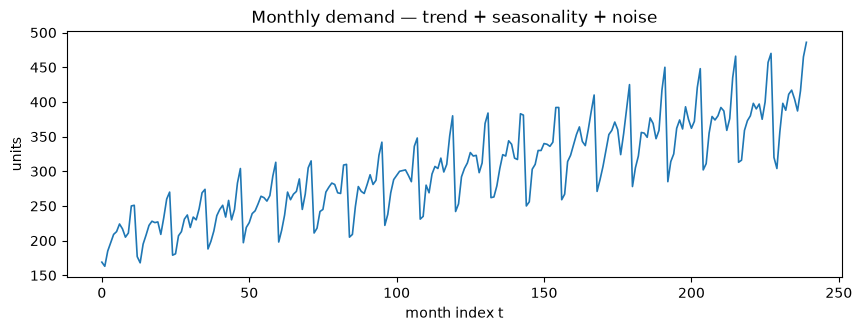

In [4]:
dataset = raw.copy()
print(dataset.isna().sum())          # no missing values expected
dataset['t'] = np.arange(len(dataset))
dataset['month_of_year'] = (dataset['t'] % 12) + 1

plt.figure(figsize=(10,3.2))
plt.plot(dataset['t'], dataset['demand'], lw=1.2)
plt.title('Monthly demand — trend + seasonality + noise')
plt.xlabel('month index t'); plt.ylabel('units'); plt.show()

## Cell 5 — YOUR TURN: build the training table
Seasonality enters the way a **categorical predictor** enters a regression — as 0/1 dummy variables: twelve switches, exactly one of them on ("one-hot").
The lag columns are the **sliding window** from the lecture diagram, slid over the whole history at once with `shift()`.

**Blanks:** (1) how many lags does the window hold? — `range(1, N)` produces 1 … N−1.  (2) which column is the label — the thing we are predicting?

**What the last line prints.** `print(dataset.shape)` shows `(rows, columns)`. Expect **(228, 28)**: the first 12 months (all of 2005) have no full year behind them, so their lag cells are empty (NaN) and `dropna()` removes them → 240 − 12 = 228 rows; the 28 columns are month + demand + t + 12 switches + 12 lags + label — only the 24 in the middle will feed the network.

In [5]:
# one-hot month (12 columns: m_1 ... m_12)
dataset = pd.get_dummies(dataset, columns=['month_of_year'], prefix='m', dtype='float32')

# lag features: lag_k = demand k months earlier   (the window, slid over the history)
for k in range(1, 13):
    dataset[f'lag_{k}'] = dataset['demand'].shift(k)

dataset['label_next'] = dataset['demand']      # the answer key: THIS month's demand, predicted from the previous 12
dataset = dataset.dropna().reset_index(drop=True)   # the first 12 rows have no full window
print(dataset.shape)
dataset.head(2)

(228, 28)


,month,demand,t,m_1,m_2,m_3,m_4,m_5,m_6,m_7,...,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,label_next
0,2006-01,177,12,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,205.0,217.0,224.0,213.0,209.0,197.0,185.0,163.0,169.0,177
1,2006-02,168,13,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,211.0,205.0,217.0,224.0,213.0,209.0,197.0,185.0,163.0,168


In [6]:
# CHECK — Cell 5
assert len([c for c in dataset.columns if c.startswith('lag_')]) == 12, 'expected 12 lag columns — check range(1, N)'
assert (dataset['label_next'] == dataset['demand']).all(), 'the label must be the demand column'
assert dataset.shape == (228, 28), f'expected (228, 28), got {dataset.shape}'
print('✓ Cell 5 check passed: 228 rows (240 minus the first 12, which have no full window); 24 inputs = 12 lags + 12 month switches; 1 label')

✓ Cell 5 check passed: 228 rows (240 minus the first 12, which have no full window); 24 inputs = 12 lags + 12 month switches; 1 label


## Cell 6 — YOUR TURN: train/test split
**Time-series rule:** never split at random — the test set must be the *future*. We hold out the last 20% of months.

**Blanks:** the training fraction, and which slice is the past (train) vs. the future (test). `iloc[:split]` = rows before `split`; `iloc[split:]` = rows from `split` on.

In [7]:
split = int(len(dataset) * 0.8)
train_dataset = dataset.iloc[:split].copy()     # the past
test_dataset  = dataset.iloc[split:].copy()     # the future
print(len(train_dataset), 'train months |', len(test_dataset), 'test months')

182 train months | 46 test months


In [8]:
# CHECK — Cell 6
assert len(train_dataset) == 182 and len(test_dataset) == 46, 'expected 182 train / 46 test'
assert test_dataset['t'].min() > train_dataset['t'].max(), 'the test set must come AFTER the training set'
print('✓ Cell 6 check passed: train = past, test = future')

✓ Cell 6 check passed: train = past, test = future


## Cell 7 — Split features and labels

In [9]:
feature_cols = [f'lag_{k}' for k in range(1,13)] + [c for c in dataset.columns if c.startswith('m_')]

train_features = train_dataset[feature_cols].astype('float32')
test_features  = test_dataset[feature_cols].astype('float32')
train_labels   = train_dataset['label_next'].astype('float32')
test_labels    = test_dataset['label_next'].astype('float32')
print(train_features.shape, test_features.shape)   # 24 inputs per row

(182, 24) (46, 24)


## Cell 8 — Normalization layer
Same role as scaling by 100 in the hand-worked example: keep every input in a friendly range. Means and s.d. are learned from the **training** rows only.

In [10]:
normalizer = layers.Normalization(axis=-1)
normalizer.adapt(np.array(train_features))

## Cell 9 — Check normalization on one sample

In [11]:
first = np.array(train_features[:1])
print('raw   :', first[0][:6].round(1), '...')
print('normed:', normalizer(first).numpy()[0][:6].round(2), '...')

raw   : [251. 250. 211. 205. 217. 224.] ...
normed: [-0.67 -0.68 -1.38 -1.48 -1.25 -1.11] ...


## Cell 10 — YOUR TURN: build & compile the model
Two hidden layers — the architecture family from the perceptron → deep-network slides.

**Blanks:** (1) the activation that introduces non-linearity (the one used in the hand-worked example); (2) how many outputs a network that predicts *one quantity* needs; (3) the loss — we want the objective J(W) to be the forecaster's MAD (Keras calls it `'mean_absolute_error'`; the alternative would be `'mean_squared_error'`).

In [12]:
model = keras.Sequential([
    normalizer,
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1),
])
model.compile(optimizer=keras.optimizers.Adam(0.01), loss='mean_absolute_error')
model.build(input_shape=(None, 24))   # tell Keras the input size, so summary() can count the weights
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 24)             │            49 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,874 (22.95 KB)

 Trainable params: 5,825 (22.75 KB)

 Non-trainable params: 49 (200.00 B)

In [13]:
# CHECK — Cell 10
model.build((None, train_features.shape[1]))   # (already built above; harmless to repeat)
assert model.layers[1].activation.__name__ == 'relu', 'hidden layers should use ReLU'
assert model.layers[-1].units == 1, 'one output unit: we predict one number'
assert model.count_params() == 5825 + 49, f'expected 5,825 trainable weights (+49 normalization stats), got {model.count_params()}'
assert 'absolute' in str(model.loss), 'use mean absolute error (MAD) as the loss'
print('✓ Cell 10 check passed: 24 → 64 → 64 → 1, MAE loss')

✓ Cell 10 check passed: 24 → 64 → 64 → 1, MAE loss


## Cell 11 — Train model
Watch gradient descent do what Section 5 of Lecture 0 promised: walk downhill on the loss. Training uses **early stopping** — the regularization idea from the lecture: keep going while the validation loss improves, stop when it stalls, keep the best weights. (About 20–40 seconds.)

**Three blocks, three jobs.** `validation_split=0.2` sets aside the *last* 37 of the 182 training rows: the network updates its weights on the other **145** (train), is scored after every epoch on the **37** (validation — this is what early stopping watches), and the **46** future months (test) are touched only once, in Cell 13, for the scorecard.

In [14]:
# Early stopping (Regularization 2 from the lecture): stop when validation loss
# has not improved for 40 epochs, and keep the best weights seen.
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=40,
                                           restore_best_weights=True)

history = model.fit(
    train_features, train_labels,
    epochs=300, validation_split=0.2,
    callbacks=[early_stop], verbose=0)

print('epochs run:', len(history.history['loss']),
      '| best validation loss (MAE):', round(min(history.history['val_loss']), 2))

epochs run: 64 | best validation loss (MAE): 8.05


## Cell 12 — Plot training history
Training vs. validation loss — if they diverge, that is the overfitting slide in action.

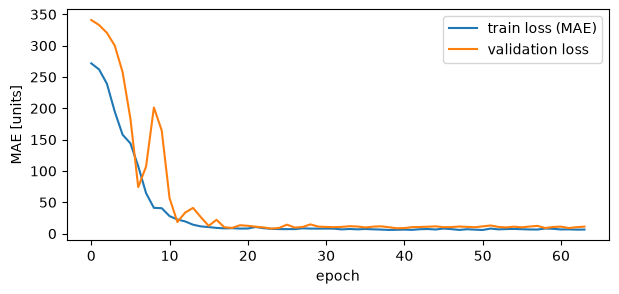

In [15]:
plt.figure(figsize=(7,3))
plt.plot(history.history['loss'], label='train loss (MAE)')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('epoch'); plt.ylabel('MAE [units]'); plt.legend(); plt.show()

## Cell 13 — YOUR TURN: score like a forecaster
We judge with the **same metrics as Part 2 of the lecture** — MAD and MAPE — against two free baselines.

**Blanks:** (1) write MAD as code: the mean of the absolute errors `f − a` (`np.mean`, `np.abs`); (2) the two baselines are just lag columns — *copy last month* and *copy the same month last year*.

In [16]:
pred = model.predict(test_features, verbose=0).flatten()
actual = test_labels.values

def mad(a, f):  return np.mean(np.abs((f - a)))
def mape(a, f): return np.mean(np.abs((f - a) / a)) * 100

# Baselines: naive (copy last month) and seasonal-naive (copy the same month last year)
naive  = test_dataset['lag_1'].values
snaive = test_dataset['lag_12'].values

print(f"Neural network : MAD = {mad(actual, pred):6.2f}   MAPE = {mape(actual, pred):5.2f}%")
print(f"Naive (lag-1)  : MAD = {mad(actual, naive):6.2f}   MAPE = {mape(actual, naive):5.2f}%")
print(f"Seasonal naive : MAD = {mad(actual, snaive):6.2f}   MAPE = {mape(actual, snaive):5.2f}%")

Neural network : MAD =  13.58   MAPE =  3.57%
Naive (lag-1)  : MAD =  30.57   MAPE =  8.40%
Seasonal naive : MAD =  11.20   MAPE =  2.91%


In [17]:
# CHECK — Cell 13
assert abs(mad(np.array([1., 2., 3.]), np.array([1., 4., 3.])) - 2/3) < 1e-9, 'mad() should return the mean absolute error'
assert abs(mad(actual, naive) - 30.6) < 0.5, 'naive should copy LAST month (MAD ≈ 30.6)'
assert abs(mad(actual, snaive) - 11.2) < 0.5, 'seasonal naive should copy the same month LAST YEAR (MAD ≈ 11.2)'
print('✓ Cell 13 check passed')

✓ Cell 13 check passed


## Cell 14 — Make predictions (picture)

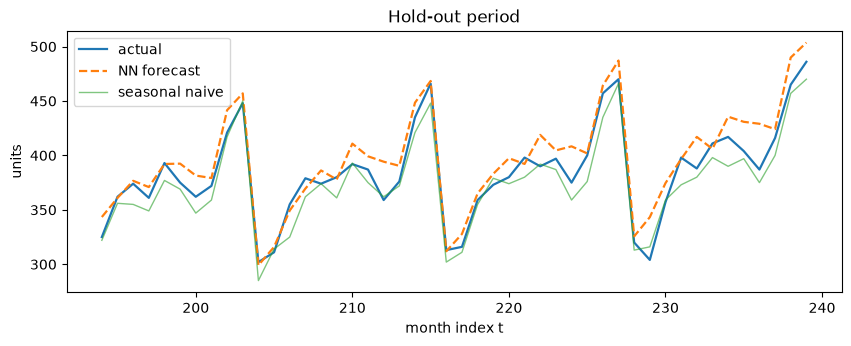

In [18]:
plt.figure(figsize=(10,3.4))
plt.plot(test_dataset['t'], actual, label='actual', lw=1.6)
plt.plot(test_dataset['t'], pred, label='NN forecast', lw=1.6, ls='--')
plt.plot(test_dataset['t'], snaive, label='seasonal naive', lw=1, alpha=0.6)
plt.xlabel('month index t'); plt.ylabel('units'); plt.legend(); plt.title('Hold-out period'); plt.show()

## Cell 15 — Quick prediction table

In [19]:
out = test_dataset[['month']].copy()
out['actual'] = actual.astype(int)
out['nn_forecast'] = np.round(pred.astype(float), 1)
out['error'] = (out['nn_forecast'] - out['actual']).round(1)
out.tail(12)

,month,actual,nn_forecast,error
216,2024-01,320,325.6,5.6
217,2024-02,304,343.3,39.3
218,2024-03,357,374.5,17.5
219,2024-04,398,396.6,-1.4
220,2024-05,388,417.0,29.0
221,2024-06,411,406.0,-5.0
222,2024-07,417,435.6,18.6
223,2024-08,404,430.9,26.9
224,2024-09,387,429.1,42.1
225,2024-10,416,424.1,8.1


## Cell 16 — (Optional) Export the model
A trained network is an artifact you can ship to other software. This step is optional — skip it if it errors.

In [20]:
try:
    import tf2onnx, onnx
    spec = (tf.TensorSpec((None, len(feature_cols)), tf.float32, name='x'),)
    onnx_model, _ = tf2onnx.convert.from_keras(model, input_signature=spec, opset=13)
    onnx.save(onnx_model, 'demand_nn.onnx')
    print('saved demand_nn.onnx')
except Exception as e:
    print('Export skipped (tf2onnx not installed or not compatible) — optional step, nothing to fix.')

Export skipped (tf2onnx not installed or not compatible) — optional step, nothing to fix.


## Cell 17 — Read the scorecard like a forecaster

You should see roughly: **naive ≈ 30**, **network ≈ 12–16**, **seasonal naive ≈ 11** (MAD, units). Exact numbers vary run to run — training is stochastic.

So the network beats "copy last month" by a factor of two, yet a *free* baseline — "copy the same month last year" — beats the network. Discuss with your partner; we compare answers in the debrief:

1. Why is seasonal naive so strong on **this** series? (Hint: how was the series built — what does seasonal naive assume?)
2. The test months are the **future**: their demand level is higher than anything in the training set. Which method suffers from that, and why?
3. We trained on 182 rows. Is that a lot for a network with ~5,800 weights?

**The lesson of Part 2 of the lecture, in practice: a model is only as good as the baseline it beats.**

## Cell 18 — YOUR TURN: Challenge — stand on the baseline's shoulders

Practitioners rarely ask a network to forecast demand from scratch. They ask it to forecast **what the baseline misses**:

$$\hat A_t = \underbrace{A_{t-12}}_{\text{seasonal naive}} + \underbrace{f(x_t; W)}_{\text{network learns the correction}}$$

Same inputs, same architecture — only the **target** changes. This is the lecture's remark that associative models can be used to *correct* time-series models.

**Blank:** the residual target is the demand minus the seasonal-naive forecast — which lag column is that?

In [21]:
# Train the SAME network on the residual target: what seasonal naive gets wrong
res_train = train_labels - train_dataset['lag_12'].astype('float32')

model_res = keras.Sequential([
    normalizer,
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1),
])
model_res.compile(optimizer=keras.optimizers.Adam(0.01), loss='mean_absolute_error')
model_res.fit(train_features, res_train, epochs=300, validation_split=0.2,
              callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=40,
                                                       restore_best_weights=True)], verbose=0)

pred_res = snaive + model_res.predict(test_features, verbose=0).flatten()

print(f"Seasonal naive        : MAD = {mad(actual, snaive):6.2f}   MAPE = {mape(actual, snaive):5.2f}%")
print(f"Network (from scratch): MAD = {mad(actual, pred):6.2f}   MAPE = {mape(actual, pred):5.2f}%")
print(f"Baseline + network    : MAD = {mad(actual, pred_res):6.2f}   MAPE = {mape(actual, pred_res):5.2f}%")

Seasonal naive        : MAD =  11.20   MAPE =  2.91%
Network (from scratch): MAD =  13.58   MAPE =  3.57%
Baseline + network    : MAD =   9.06   MAPE =  2.42%


In [22]:
# CHECK — Cell 18
assert res_train.abs().mean() < 20, 'the residual should be small: subtract the SAME MONTH LAST YEAR (lag_12)'
print('✓ Cell 18 check passed — typical result: baseline + network ≈ 8–9 MAD, the first model to beat the seasonal naive')

✓ Cell 18 check passed — typical result: baseline + network ≈ 8–9 MAD, the first model to beat the seasonal naive


Typically the combination lands around **MAD ≈ 8–9** — the first model in this notebook to beat the seasonal naive, and it does so reliably. Nothing about the network changed; we only chose a smarter question to ask it.

## Cell 19 — Experiment helper (provided; nothing to fill in)

If you are ahead of pace, or curious after class, you can change *one* thing about the model and see what happens. This function rebuilds the table, trains, and scores — so an experiment is a single call. Run this cell once as-is.

window=12  use_month=True  lr=0.01  early_stopping=True  |  epochs run: 80
  network        : MAD =  14.40   MAPE =  3.86%
  naive          : MAD =  30.57   MAPE =  8.40%
  seasonal naive : MAD =  11.20   MAPE =  2.91%


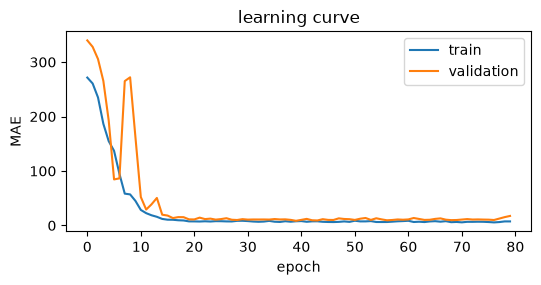

In [23]:
def train_and_score(window=12, use_month=True, lr=0.01, early_stopping=True, seed=510, show=True):
    """Rebuild the training table from `raw`, train the lecture network, and score it.
    window        : how many lag months the network sees
    use_month     : include the 12 month one-hot switches?
    lr            : Adam learning rate
    early_stopping: stop when validation stalls (patience 40) and keep the best weights
    Returns a dict with the scorecard (MAD/MAPE) and the training history."""
    np.random.seed(seed); tf.random.set_seed(seed)
    d = raw.copy(); d['t'] = np.arange(len(d)); d['month_of_year'] = (d['t'] % 12) + 1
    d = pd.get_dummies(d, columns=['month_of_year'], prefix='m', dtype='float32')
    for k in range(1, window + 1):
        d[f'lag_{k}'] = d['demand'].shift(k)
    d['lag_12_ref'] = d['demand'].shift(12)            # for the seasonal-naive baseline, whatever the window
    d = d.dropna().reset_index(drop=True)
    cols = [f'lag_{k}' for k in range(1, window + 1)] + ([c for c in d.columns if c.startswith('m_')] if use_month else [])
    split = int(len(d) * 0.8); tr, te = d.iloc[:split], d.iloc[split:]
    Xtr, Xte = tr[cols].astype('float32'), te[cols].astype('float32')
    ytr, yte = tr['demand'].astype('float32'), te['demand'].astype('float32').values
    norm = layers.Normalization(axis=-1); norm.adapt(np.array(Xtr))
    m = keras.Sequential([norm, layers.Dense(64, activation='relu'), layers.Dense(64, activation='relu'), layers.Dense(1)])
    m.compile(optimizer=keras.optimizers.Adam(lr), loss='mean_absolute_error')
    cb = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True)] if early_stopping else []
    h = m.fit(Xtr, ytr, epochs=300 if early_stopping else 200, validation_split=0.2, callbacks=cb, verbose=0)
    p = m.predict(Xte, verbose=0).flatten()
    nv, sn = te['lag_1'].values, te['lag_12_ref'].values
    card = {'network': (mad(yte, p), mape(yte, p)), 'naive': (mad(yte, nv), mape(yte, nv)), 'seasonal naive': (mad(yte, sn), mape(yte, sn))}
    if show:
        print(f"window={window}  use_month={use_month}  lr={lr}  early_stopping={early_stopping}  |  epochs run: {len(h.history['loss'])}")
        for k, (a_, b_) in card.items(): print(f"  {k:15s}: MAD = {a_:6.2f}   MAPE = {b_:5.2f}%")
        plt.figure(figsize=(6,2.6)); plt.plot(h.history['loss'], label='train'); plt.plot(h.history['val_loss'], label='validation')
        plt.xlabel('epoch'); plt.ylabel('MAE'); plt.legend(); plt.title('learning curve'); plt.show()
    return {'scorecard': card, 'history': h.history}

baseline_run = train_and_score()   # the lab configuration, for reference

## Cell 20 — Optional: try one change

Change **exactly one** argument and run, then compare the scorecard and the learning curve with the reference run above. For example, `train_and_score(window=3)` trains the same network with a three-month window. Which lecture concept explains what you see?

window=12  use_month=False  lr=0.01  early_stopping=True  |  epochs run: 63
  network        : MAD =   8.77   MAPE =  2.31%
  naive          : MAD =  30.57   MAPE =  8.40%
  seasonal naive : MAD =  11.20   MAPE =  2.91%


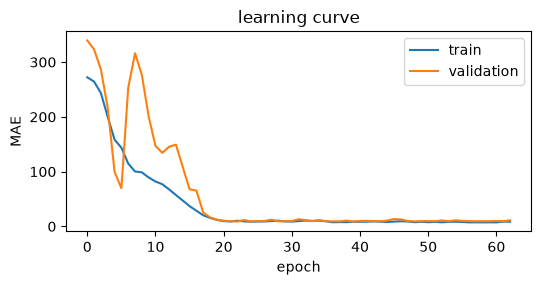

In [24]:
# Example — replace the argument with the one you chose:
my_run = train_and_score(use_month=False)

---
### Final-project hook
Keep this notebook (File › Save a copy in Drive). The final group project extends it: **classical methods (ES / DES / TES / regression) vs. this network — same data, same MAD/MAPE scorecard, same held-out months.**